2023-11-12 18:45:01,736 - INFO - tvb_multiscale.tvb_nest.config - Configuring NEST path...
2023-11-12 18:45:01,736 - INFO - tvb_multiscale.tvb_nest.config - Configuring NEST path...
2023-11-12 18:45:01,738 - INFO - tvb_multiscale.tvb_nest.config - NEST_INSTALL_DIR: /home/docker/build/nest
2023-11-12 18:45:01,738 - INFO - tvb_multiscale.tvb_nest.config - NEST_INSTALL_DIR: /home/docker/build/nest
2023-11-12 18:45:01,739 - INFO - tvb_multiscale.tvb_nest.config - NEST_DATA_DIR: /home/docker/build/nest/share/nest
2023-11-12 18:45:01,739 - INFO - tvb_multiscale.tvb_nest.config - NEST_DATA_DIR: /home/docker/build/nest/share/nest
2023-11-12 18:45:01,741 - INFO - tvb_multiscale.tvb_nest.config - NEST_DOC_DIR: /home/docker/build/nest/share/doc/nest
2023-11-12 18:45:01,741 - INFO - tvb_multiscale.tvb_nest.config - NEST_DOC_DIR: /home/docker/build/nest/share/doc/nest
2023-11-12 18:45:01,742 - INFO - tvb_multiscale.tvb_nest.config - NEST_MODULE_PATH: /home/docker/build/nest/lib/nest
2023-11-12 18:4

Outputs' path: /home/docker/packages/tvb-multiscale/rising_net/working_files/results_cerebOFF_noise_seed_9
Config (
  title ........................................................................................... 'Config gid: e5f50f9b-e8af-4eb2-aa68-50c98f92ddd1'
  Type ............................................................................................ 'Config'
  gid ............................................................................................. UUID('e5f50f9b-e8af-4eb2-aa68-50c98f92ddd1')
  config.gid ...................................................................................... UUID('e5f50f9b-e8af-4eb2-aa68-50c98f92ddd1')
  config.title .................................................................................... 'Config gid: e5f50f9b-e8af-4eb2-aa68-50c98f92ddd1'
  config.log ...................................................................................... <Logger tvb_multiscale.tvb_nest.config (DEBUG)>
  config.BASEPATH .................

Fixing thalamocortical weights!
Fixing thalamocortical delays!
Applying FIC for parameter I_e: G * FIC * FIC_SPLIT = 6 * 1.11 * 0.31 = 2.0646!


/home/docker/packages/tvb-multiscale/rising_net/scripts/tvb_script.py:305: UserWarning: 
  warnings.warn(str(e))


<Figure size 432x288 with 0 Axes>

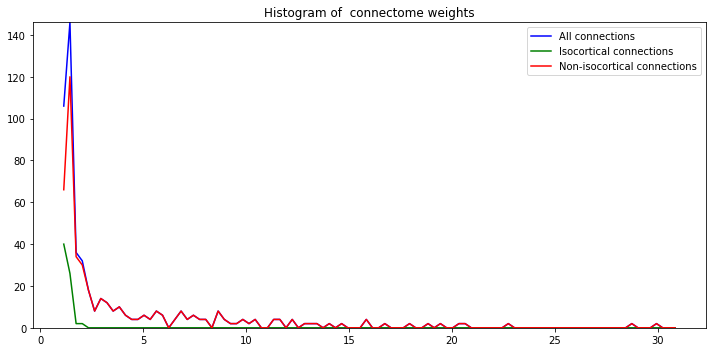

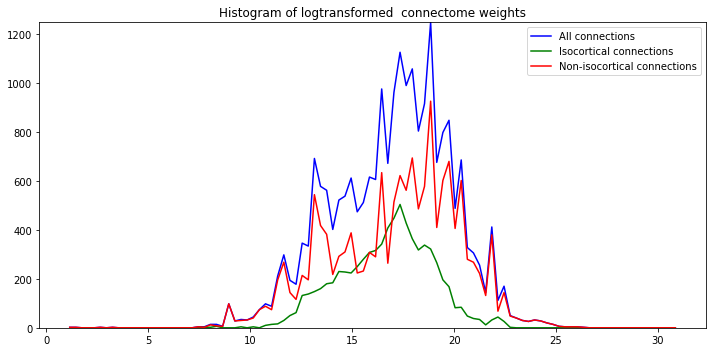

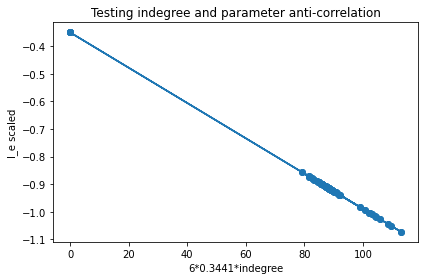

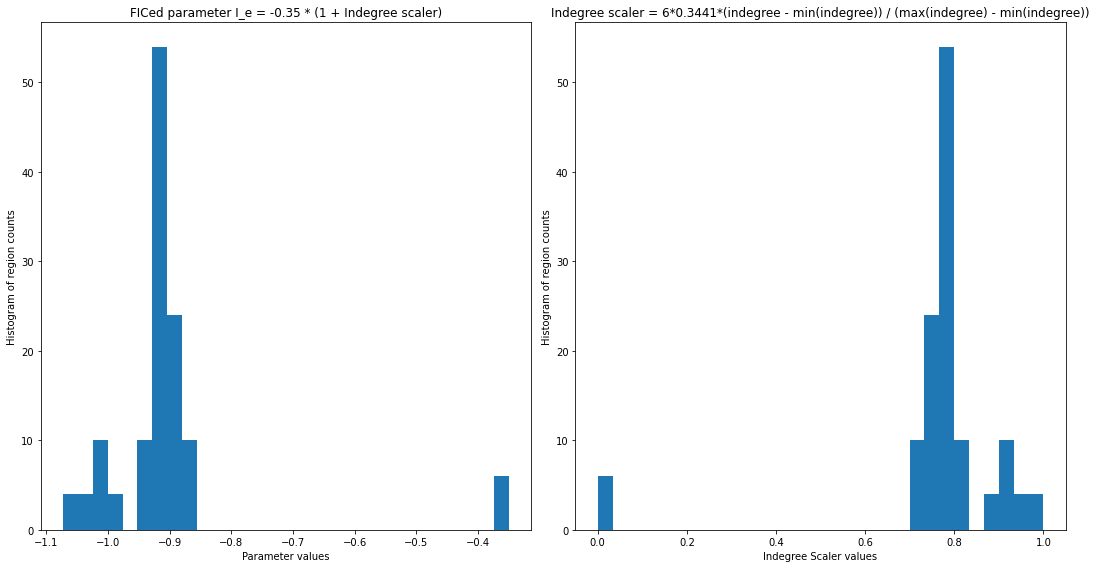

Applying FIC for parameter w_ie: G * FIC * (1.0-FIC_SPLIT) = 6 * 1.11 * 0.69 = 4.5954!


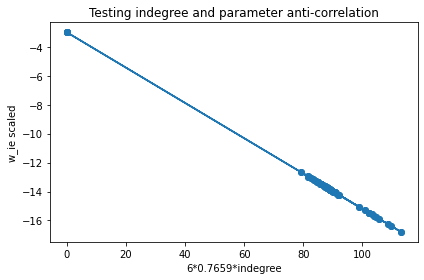

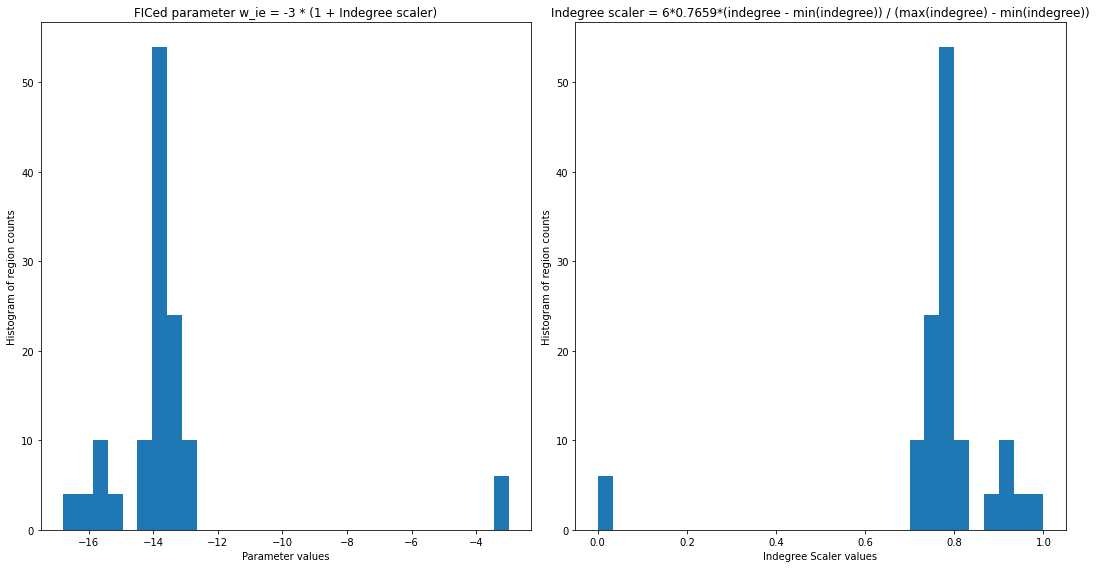

2023-11-12 18:45:02,559 - WARNING - tvb_multiscale.core.tvb.cosimulator.cosimulator_serial - There are no existing connections (i.e., with nonzero weights)!
Setting minimum delay to 1 integrator time step = 0.1!.
2023-11-12 18:45:02,559 - WARNING - tvb_multiscale.core.tvb.cosimulator.cosimulator_serial - Current step is not 0 upon configuration!
Setting it to 0. Initial condition might be affected!
Current step is not 0 upon configuration!
Setting it to 0. Initial condition might be affected!
CoSimulatorSerial (
  title ............................... 'CoSimulatorSerial gid: 45e4244a-fa78-47fe-b4c6-559f17e4590b'
  Type ................................ 'CoSimulatorSerial'
  model ............................... WilsonCowanThalamoCortical gid: ded8cc0e-8e7f-4c8e-99fb-7898e83ca56c
  output_interfaces ................... None
  input_interfaces .................... None
  out_proxy_inds ...................... --------------------
  shape ............................... (0,)
  dtype .......


KeyboardInterrupt



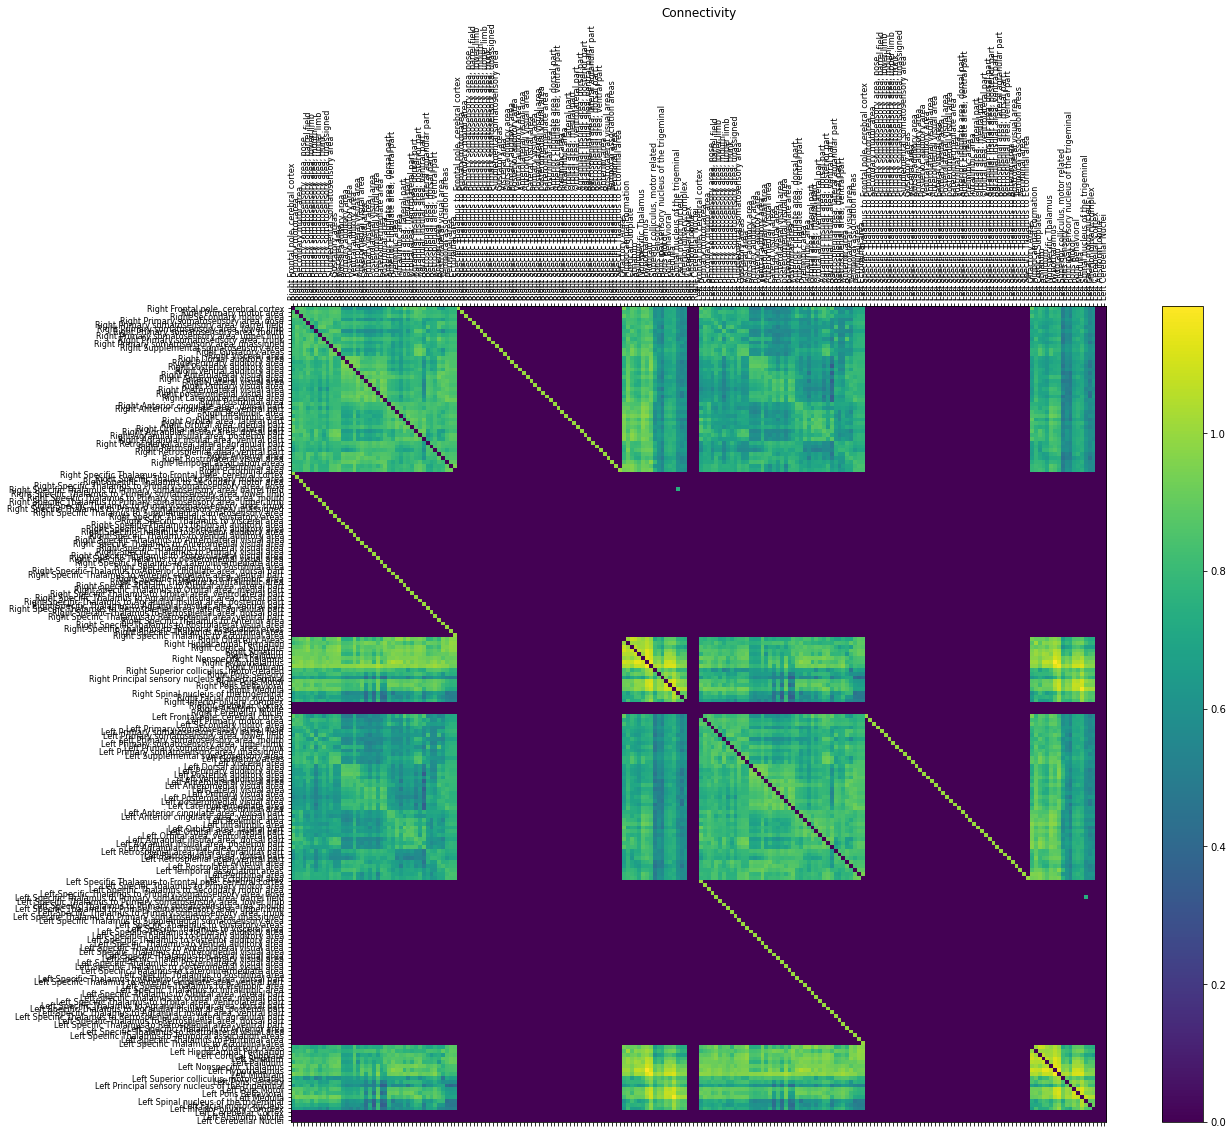

In [1]:
from rising_net.scripts.tvb_nest_script import *
from rising_net.scripts.nest_script import *        #build_NEST_network, plot_nest_results

from tvb_multiscale.core.plot.plotter import Plotter

from tvb.contrib.scripts.datatypes.time_series_xarray import TimeSeriesRegion as TimeSeriesXarray



# Assuming:
# DEFAULT_ARGS = {'G': 6.0, 'STIMULUS': 0.1,
#                 'I_e': -0.35, 'I_s': 0.085,
#                 'w_ie': -3.0, 'w_rs': -2.0,
#                 'CONN_LOG': True, 'FIC': 1.11,  'FIC_SPLIT': 0.31,  #'fit',
#                 'PRIORS_DIST': 'uniform',
#                 'output_folder': "", 'verbose': 1, 'plot_flag': True}

# config.TRANSIENT_RATIO =0.25
# # TVB - NEST interface parameters:
# config.MOSSY_MAX_RATE = 122.0  # Hz
# config.w_TVB_to_NEST = 0.04

seed = 9
test_name = 'cerebOFF'              # 'cosim', 'tvb-only', 'cerebOFF'
if test_name=='cosim':
    COMPUTE_REF = False          # True if you want to run TVB-only
    CEREB_OFF = False
elif test_name=='tvb-only':
    COMPUTE_REF = True
    CEREB_OFF = False
elif test_name == 'cerebOFF':
    COMPUTE_REF = True
    CEREB_OFF = True

resfilename = "results_%s_noise_seed_%d" % (test_name, seed)
path = os.path.join(os.getcwd(), resfilename)
# Get configuration
config, plotter = configure(output_folder=path, verbose=2)
config.SIMULATION_LENGTH = 30000.0
config.RANDOM_SEED_TVB = seed
config.RANDOM_SEED_NEST = seed

# Load and prepare connectome and connectivity with all possible normalizations:
connectome, major_structs_labels, voxel_count, inds, maps = prepare_connectome(config, plotter=plotter)
connectivity = build_connectivity(connectome, inds, config)

# # Scale up connections from principal sensory trigeminal nucleus to ansiform lobule
# reg1='Left Ansiform lobule'
# reg2='Right Ansiform lobule'
# reg3 = 'Left Principal sensory nucleus of the trigeminal'
# reg4 = 'Right Principal sensory nucleus of the trigeminal'
# reg5 = 'Left Spinal nucleus of the trigeminal'
# reg6 = 'Right Spinal nucleus of the trigeminal'
# #find the indices in region labels of these strings
# iR1 = np.where([reg1 in reg for reg in connectivity.region_labels])[0]
# iR2 = np.where([reg2 in reg for reg in connectivity.region_labels])[0]
# iR3 = np.where([reg3 in reg for reg in connectivity.region_labels])[0]
# iR4 = np.where([reg4 in reg for reg in connectivity.region_labels])[0]
# iR5 = np.where([reg5 in reg for reg in connectivity.region_labels])[0]
# iR6 = np.where([reg6 in reg for reg in connectivity.region_labels])[0]
#
# pathway_gain = 1
# '''# PST to AN
# connectivity.weights[iR1, iR3] *= pathway_gain
# connectivity.weights[iR1, iR4] *= pathway_gain
# connectivity.weights[iR2, iR3] *= pathway_gain
# connectivity.weights[iR2, iR4] *= pathway_gain
# # SNT to PST
# connectivity.weights[iR3, iR5] *= pathway_gain
# connectivity.weights[iR3, iR6] *= pathway_gain
# connectivity.weights[iR4, iR5] *= pathway_gain
# connectivity.weights[iR4, iR6] *= pathway_gain
# '''
# # SNT to AN
# connectivity.weights[iR1, iR5] *= pathway_gain
# connectivity.weights[iR1, iR6] *= pathway_gain
# connectivity.weights[iR2, iR5] *= pathway_gain
# connectivity.weights[iR2, iR6] *= pathway_gain

# # To have the full sensory whisking pathway
# reg7 = 'Left Primary somatosensory area, barrel field'
# reg8 = 'Right Primary somatosensory area, barrel field'
# iR7 = np.where([reg7 in reg for reg in connectivity.region_labels])[0]
# iR8 = np.where([reg8 in reg for reg in connectivity.region_labels])[0]
# # S1 to PST
# connectivity.weights[iR3, iR7] *= pathway_gain
# connectivity.weights[iR3, iR8] *= pathway_gain
# connectivity.weights[iR4, iR7] *= pathway_gain
# connectivity.weights[iR4, iR8] *= pathway_gain
# # SNT to S1
# connectivity.weights[iR7, iR5] *= pathway_gain
# connectivity.weights[iR7, iR6] *= pathway_gain
# connectivity.weights[iR8, iR5] *= pathway_gain
# connectivity.weights[iR8, iR6] *= pathway_gain


# Put cereb weights to 0 if CEREB_OFF
if CEREB_OFF:
    #reg1='Cerebell*'
    reg1='Left Cerebellar Cortex'
    reg2='Left Cerebellar Nuclei'
    reg3='Left Ansiform lobule'
    reg4='Left Interposed nucleus'
    reg5='Right Cerebellar Cortex'
    reg6='Right Cerebellar Nuclei'
    reg7='Right Ansiform lobule'
    reg8='Right Interposed nucleus'
    #find the indices in region labels of these strings
    iR1 = np.where([reg1 in reg for reg in connectivity.region_labels])[0]
    iR2 = np.where([reg2 in reg for reg in connectivity.region_labels])[0]
    iR3 = np.where([reg3 in reg for reg in connectivity.region_labels])[0]
    iR4 = np.where([reg4 in reg for reg in connectivity.region_labels])[0]
    iR5 = np.where([reg5 in reg for reg in connectivity.region_labels])[0]
    iR6 = np.where([reg6 in reg for reg in connectivity.region_labels])[0]
    iR7 = np.where([reg7 in reg for reg in connectivity.region_labels])[0]
    iR8 = np.where([reg8 in reg for reg in connectivity.region_labels])[0]
    # for reg1, reg2, sc in config.BRAIN_CONNECTIONS_TO_SCALE:
    #     iR1 = np.where([reg in reg1 for reg in connectivity.region_labels])[0]
    #     iR2 = np.where([reg in reg2 for reg in connectivity.region_labels])[0]
    #     connectivity.weights[iR1, iR2] *= 0
    #iR1
    connectivity.weights.shape
    for i in [iR1, iR2, iR3, iR4, iR5, iR6, iR7, iR8]:
        connectivity.weights[i,:]=0
        connectivity.weights[:,i]=0
                        # , iR2, iR3, iR4, iR5, iR6, iR7, iR8] = 0
    connectivity.weights[iR1,:]


# Prepare model
model = build_model(connectivity.number_of_regions, inds, maps, config)

# Prepare simulator
simulator = build_simulator(connectivity, model, inds, maps, config, plotter=plotter)

if COMPUTE_REF:
    # Run simulation and get results for reference values
    results, transient = simulate(simulator, config)
else:
    # Build TVB-NEST interfaces
    nest_network, nest_nodes_inds, neuron_models, neuron_number = build_NEST_network(config)
    simulator, nest_network = build_tvb_nest_interfaces(simulator, nest_network, nest_nodes_inds, config)
    # Simulate TVB-NEST model
    results, transient, simulator, nest_network = simulate_tvb_nest(simulator, nest_network, config)
        
print(results)
       

        
# Target values: ansilob=-0.3263, interposed=-0.3209, oliv=-0.3284


In [ ]:
# Compute coherence
transient = config.TRANSIENT_RATIO * config.SIMULATION_LENGTH
if config.RAW_PERIOD > config.DEFAULT_DT:
    transient = (transient // config.RAW_PERIOD) * config.RAW_PERIOD + config.RAW_PERIOD/2

results = plot_tvb(transient, inds,
                   results=results, simulator=simulator, plotter=plotter, config=config, write_files=True)

In [ ]:
import pickle
results_path = os.path.join(config.out.FOLDER_RES, '%s.pickle' % resfilename)
with open(results_path, 'wb') as handle:
   pickle.dump(results, handle)
print(results_path)
# results = pickle.load(results_path, 'rb'))  # to load results

In [ ]:
cohfilename = "coherence_30sec_%s_noise_seed_%d" % (test_name, seed)
coherence_path = os.path.join(config.out.FOLDER_RES, '%s.pickle' % cohfilename)
# Save coherence
CxyR = results["CxyR_M1_S1"]
fR = results["fR"]
CxyL = results["Cxyl_M1_S1"]
fL = results["fL"]
with open(coherence_path, 'wb') as handle:
    pickle.dump([CxyR, fR, fL, CxyL], handle)
print(coherence_path)

In [1]:
! pwd

/home/docker/packages/tvb-multiscale/rising_net/working_files


In [11]:
import pickle
import os
basepath = "/home/docker/packages/tvb-multiscale/rising_net/working_files/outputs" 

In [35]:
test = "cosim"
seed = 0
resultpath = "results_%s_noise_seed_%d/res" % (test, seed)
resultsfile = os.path.join(basepath, resultpath, 
                           "results_%s_noise_seed_%d.pickle" % (test, seed))
coherencefile = os.path.join(basepath, resultpath, 
                             "coherence_30sec_%s_noise_seed_%d.pickle" % (test, seed))
configfile = os.path.join(basepath, resultpath, "config.pkl")
simfile = os.path.join(basepath, resultpath, "tvb_serial_cosimulator.pkl")

In [15]:
with open(resultsfile, 'rb') as handle:
    results = pickle.load(handle)  # to load results

In [26]:
import numpy as np

np.diff(results["source_ts"].time).mean()

1.0

In [29]:
with open(configfile, 'rb') as handle:
    config = pickle.load(handle)  # to load results

In [34]:
config["RAW_PERIOD"]

1.0

In [36]:
with open(simfile, 'rb') as handle:
    sim = pickle.load(handle)  # to load results

In [40]:
sim["monitor.period"]

1.0

In [41]:
with open(coherencefile, 'rb') as handle:
    coh = pickle.load(handle)  # to load results

In [50]:
coh[2].max()

500.0

In [ ]:
Pxx_den, f, CxyR, fR, CxyL, fL = \
            compute_plot_selected_spectra_coherence(source_ts, inds["m1s1brl"],
                                                    transient=transient, nperseg=NPERSEG, 
                                                    fmin=0.0, fmax=100.0,
                                                    figures_path=config.figures.FOLDER_FIGURES,
                                                    figname="M1_S1brl", 
                                                    figformat="png",
                                                    show_flag=plotter.config.SHOW_FLAG,
                                                    save_flag=plotter.config.SAVE_FLAG)